In [2]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve, auc, \
    confusion_matrix
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [3]:
data_directory = Path(__name__).resolve().parent.parent / 'data'
model_dir = Path(__name__).resolve().parent.parent / 'models'

train_data = pd.read_csv(data_directory / 'train_data.csv')
test_data = pd.read_csv(data_directory / 'test_data.csv')

In [4]:
X_train = train_data.drop('Churn', axis=1)
y_train = train_data['Churn']
X_test = test_data.drop('Churn', axis=1)
y_test = test_data['Churn']


In [5]:
print(X_train.nunique())
print(X_train.info())

TotalCharges                               4959
MonthlyCharges                             1471
tenure                                       73
SeniorCitizen                                 2
gender                                        2
Partner                                       2
Dependents                                    2
PaperlessBilling                              2
MultipleLines_No                              2
MultipleLines_Yes                             2
InternetService_Fiber optic                   2
InternetService_No                            2
OnlineSecurity_No                             2
OnlineSecurity_No internet service            2
OnlineSecurity_Yes                            2
OnlineBackup_No                               2
OnlineBackup_No internet service              2
DeviceProtection_No                           2
DeviceProtection_No internet service          2
DeviceProtection_Yes                          2
TechSupport_No                          

In [6]:
model = Pipeline([
    ('logreg', LogisticRegression(random_state=42, class_weight='balanced')),
])

param_grid = {
    'logreg__C': [0.1],
    'logreg__penalty': ['l2'],
    'logreg__solver': ['lbfgs', 'newton-cholesky', 'sag', 'saga']
}

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search_logreg = GridSearchCV(estimator=model, param_grid=param_grid, cv=strat_kfold)
grid_search_logreg.fit(X_train, y_train)
grid_search_logreg.best_params_

{'logreg__C': 0.1,
 'logreg__penalty': 'l2',
 'logreg__solver': 'newton-cholesky'}

In [7]:
best_logreg_model = grid_search_logreg.best_estimator_
# joblib.dump(best_logreg_model, model_dir / 'best_logreg_model.pkl')

y_proba = best_logreg_model.predict_proba(X_train)[:, 1]
y_pred = (y_proba > 0.48).astype(int)
clf_report = classification_report(y_train, y_pred)
fpr, tpr, thr = roc_curve(y_train, y_proba)
roc_auc = roc_auc_score(y_train, y_proba)
precision, recall, thresholds = precision_recall_curve(y_train, y_pred)
pr_auc = auc(recall, precision)
print(f'Classification report | Train:\n{clf_report}\nroc_auc: {roc_auc: .2f}\npr_auc: {pr_auc: .2f}')

Classification report | Train:
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      3880
           1       0.51      0.81      0.62      1402

    accuracy                           0.74      5282
   macro avg       0.71      0.76      0.71      5282
weighted avg       0.80      0.74      0.75      5282

roc_auc: 0.8472554855361266
pr_auc: 0.6833220583143207


In [8]:
y_proba = best_logreg_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.48).astype(int)
clf_report = classification_report(y_test, y_pred)
fpr, tpr, thr = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
pr_auc = auc(recall, precision)
print(f'Classification report | Test:\n{clf_report}\nroc_auc: {roc_auc: .2f}\npr_auc: {pr_auc: .2f}')

Classification report | Test:
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1294
           1       0.51      0.81      0.63       467

    accuracy                           0.74      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.81      0.74      0.76      1761

roc_auc: 0.8452319881912566
pr_auc: 0.685386059282473


Text(0, 0.5, 'True positive rate')

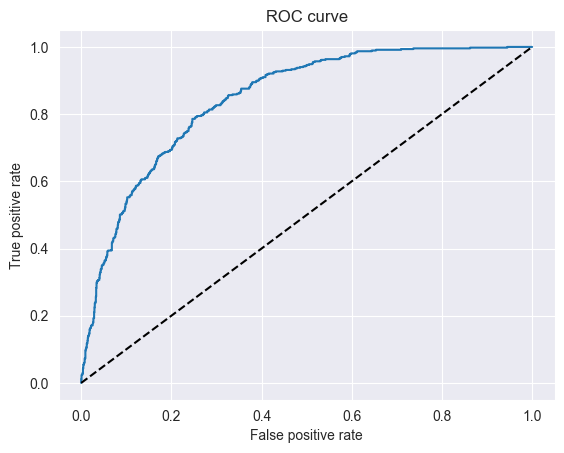

In [9]:
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

<Axes: >

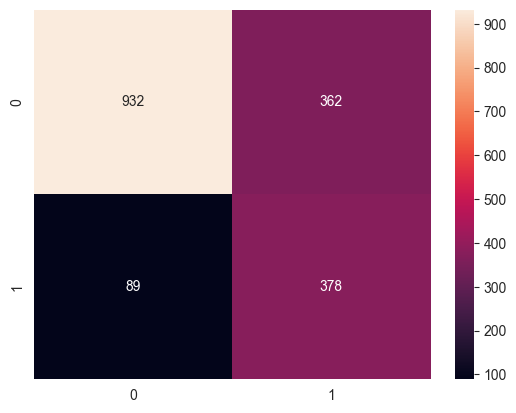

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='.4g')